# Univariate Direct Multi-step Forecasting using GRU, window=30

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tabulate import tabulate

import tensorflow as tf
from tensorflow.keras.models import Sequential

╒══════════╤═════════════╕
│ Metric   │       Value │
╞══════════╪═════════════╡
│ MAE      │ 27406.6     │
├──────────┼─────────────┤
│ RMSE     │ 36298.9     │
├──────────┼─────────────┤
│ MAPE (%) │     8.73586 │
╘══════════╧═════════════╛


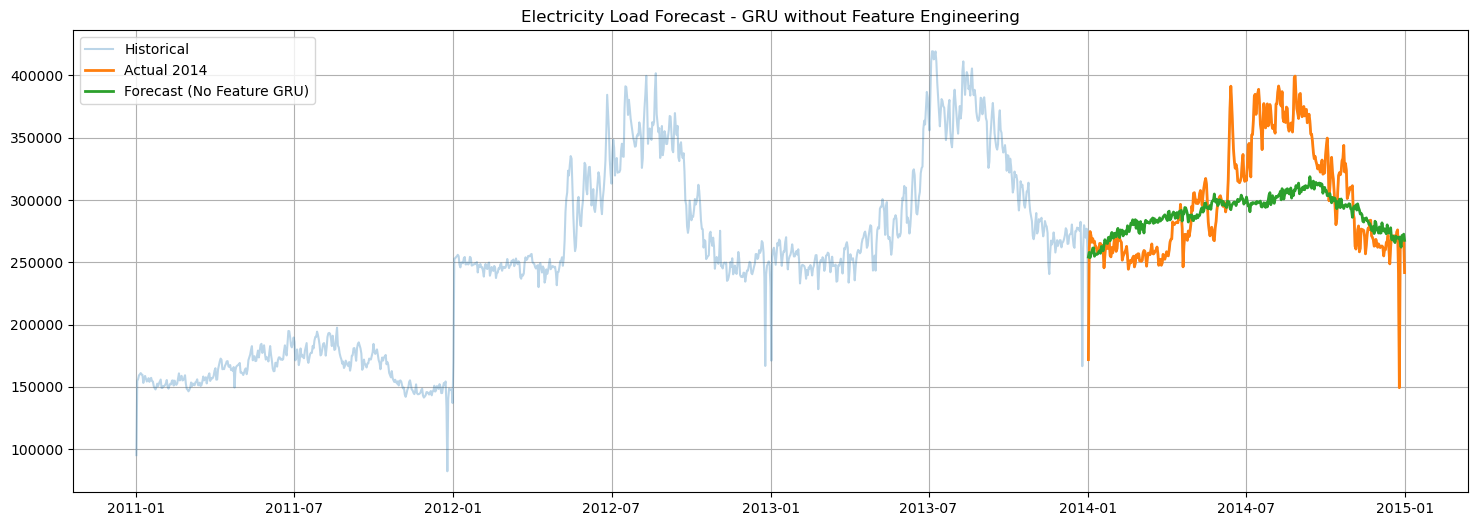

In [70]:
#load data
path = r"C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\data_cleaned\df_clean"
df = pd.read_parquet(path)
df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

df_daily = df.resample("D").sum()
df_daily["value"] = df_daily.mean(axis=1)

# only target
data = df_daily[["value"]]

# split
train_df = data[data.index < "2014-01-01"]
test_df  = data[(data.index >= "2014-01-01") & (data.index < "2015-01-01")]

# scale
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

# SEQUENCE (DIRECT MULTI-HORIZON)
window = 30
HORIZON = len(test_df)

def create_seq(data):
    X, y = [], []
    for i in range(len(data) - window - HORIZON):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+HORIZON, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_seq(train_scaled)

# models
model = Sequential([
    Input(shape=(window, 1)),

    GRU(128, return_sequences=True),
    Dropout(0.2),

    GRU(64),
    Dropout(0.2),

    Dense(128, activation="relu"),
    Dense(HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="huber"
)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)

# forecast 2014
last_window = train_scaled[-window:]

future_scaled = model.predict(
    last_window.reshape(1, window, 1),
    verbose=0
)[0]

# inverse scale
future = scaler.inverse_transform(
    future_scaled.reshape(-1,1)
)[:,0]

# ground truth
true_2014 = test_df["value"].values

min_len = min(len(true_2014), len(future))
true_2014 = true_2014[:min_len]
future = future[:min_len]

# metrics
mae = mean_absolute_error(true_2014, future)
rmse = np.sqrt(mean_squared_error(true_2014, future))
mape = np.mean(np.abs((true_2014 - future) / (true_2014 + 1e-6))) * 100

print(tabulate([
    ["MAE", mae],
    ["RMSE", rmse],
    ["MAPE (%)", mape]
], headers=["Metric", "Value"], tablefmt="fancy_grid"))

# plot
future_index = test_df.index[:min_len]

plt.figure(figsize=(18,6))

plt.plot(data.index, data["value"], alpha=0.3, label="Historical")
plt.plot(test_df.index[:min_len], true_2014, label="Actual 2014", linewidth=2)
plt.plot(future_index, future, label="Forecast (No Feature GRU)", linewidth=2)

plt.title("Electricity Load Forecast - GRU without Feature Engineering")
plt.legend()
plt.grid()
plt.show()